Name : Lathika M
Roll No : 24BAD062
Scenario 1 : Bagging
   Glucose   BMI  Age  BloodPressure  Insulin  Outcome
0      182  21.1   45             99      100        1
1      131  35.6   67             92      199        1
2      172  19.6   68             68      234        1
3       94  39.7   21            102       83        0
4      186  35.0   20            113       61        1
Decision Tree Accuracy: 1.0
Bagging Accuracy: 1.0


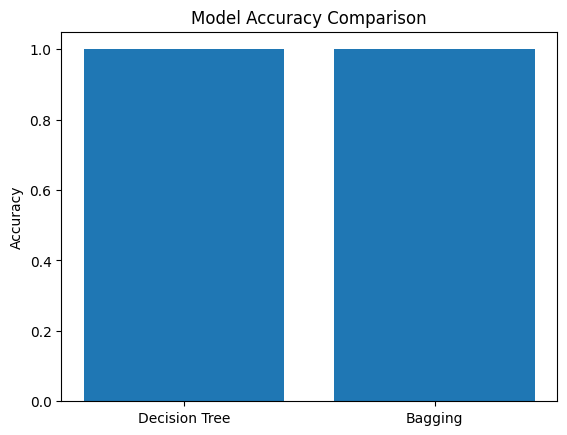

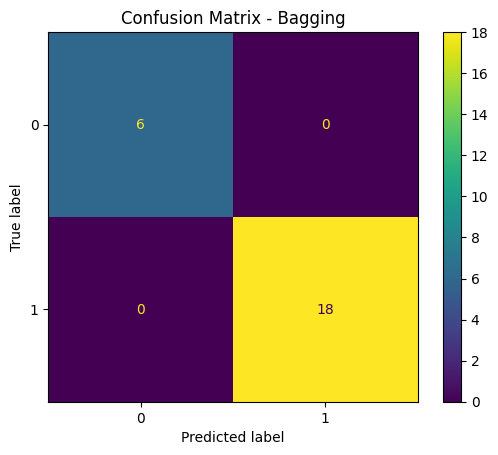

In [7]:
print("Name : Lathika M")
print("Roll No : 24BAD062")
print("Scenario 1 : Bagging")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Load dataset
data = pd.read_csv('/kaggle/input/datasets/lathikamuthuraj/diabetes-bagging-dataset/diabetes_bagging.csv')

# Display first rows
print(data.head())

# Features and Target
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)


bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)

bagging.fit(X_train, y_train)

bag_pred = bagging.predict(X_test)

bag_accuracy = accuracy_score(y_test, bag_pred)

print("Bagging Accuracy:", bag_accuracy)


models = ["Decision Tree", "Bagging"]
accuracy = [dt_accuracy, bag_accuracy]

plt.figure()
plt.bar(models, accuracy)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

cm = confusion_matrix(y_test, bag_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Bagging")
plt.show()

Name: Lathika M
Roll No: 24BAD062
Scenario 2 – Boosting (AdaBoost & Gradient Boosting)
Columns: Index(['Tenure', 'MonthlyCharges', 'ContractType', 'InternetService', 'Churn'], dtype='object')
AdaBoost Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        34
           1       1.00      1.00      1.00         2

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

Gradient Boosting Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        34
           1       1.00      1.00      1.00         2

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



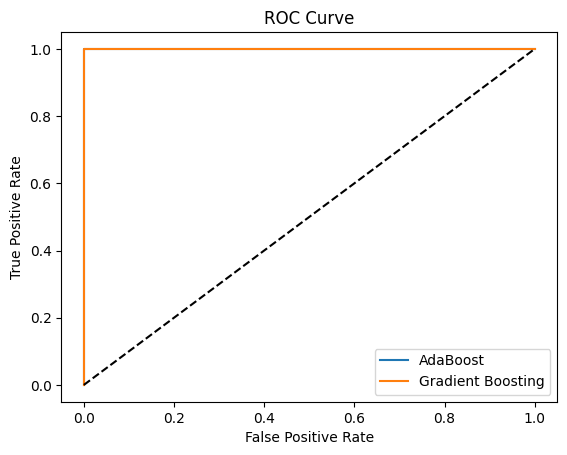

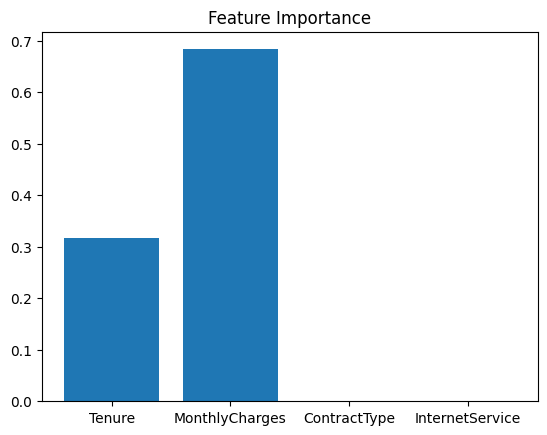

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, roc_curve
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

print("Name: Lathika M")
print("Roll No: 24BAD062")
print("Scenario 2 – Boosting (AdaBoost & Gradient Boosting)")

data = pd.read_csv("/kaggle/input/datasets/lathikamuthuraj/churn-boosting-csv/churn_boosting.csv")

data.columns = data.columns.str.strip()

print("Columns:", data.columns)

target = 'Churn'

for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = LabelEncoder().fit_transform(data[col])

X = data.drop(target, axis=1)
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),n_estimators=100)

ada.fit(X_train,y_train)

y_pred_ada = ada.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test,y_pred_ada))
print(classification_report(y_test,y_pred_ada))

gb = GradientBoostingClassifier(n_estimators=100)

gb.fit(X_train,y_train)

y_pred_gb = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test,y_pred_gb))
print(classification_report(y_test,y_pred_gb))

y_prob_ada = ada.predict_proba(X_test)[:,1]
y_prob_gb = gb.predict_proba(X_test)[:,1]

fpr_ada,tpr_ada,_ = roc_curve(y_test,y_prob_ada)
fpr_gb,tpr_gb,_ = roc_curve(y_test,y_prob_gb)

plt.figure()

plt.plot(fpr_ada,tpr_ada,label="AdaBoost")
plt.plot(fpr_gb,tpr_gb,label="Gradient Boosting")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

importance = gb.feature_importances_

plt.bar(X.columns,importance)

plt.title("Feature Importance")

plt.show()

Name: Lathika M
Roll No: 24BAD062
Scenario 3 – Random Forest
Index(['Age', 'EducationYears', 'HoursPerWeek', 'Experience', 'Income'], dtype='object')
Trees: 10 Accuracy: 1.0
Trees: 20 Accuracy: 1.0
Trees: 50 Accuracy: 1.0
Trees: 100 Accuracy: 1.0
Trees: 150 Accuracy: 1.0
Final Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00         9

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



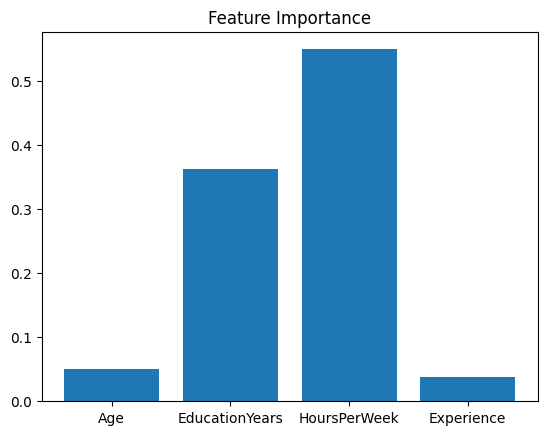

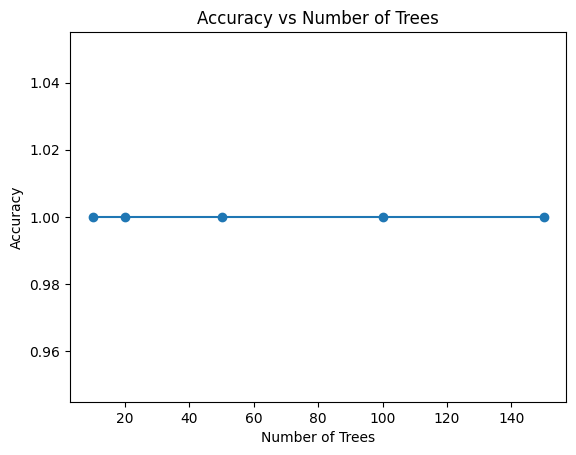

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("Name: Lathika M")
print("Roll No: 24BAD062")
print("Scenario 3 – Random Forest")

data = pd.read_csv("/kaggle/input/datasets/lathikamuthuraj/income-random-forest-csv/income_random_forest.csv")

data.columns = data.columns.str.strip()

print(data.columns)

for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = LabelEncoder().fit_transform(data[col])

X = data.iloc[:,:-1]
y = data.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

trees = [10,20,50,100,150]
accuracy_list = []

for n in trees:
    rf = RandomForestClassifier(n_estimators=n,random_state=42)
    rf.fit(X_train,y_train)
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test,y_pred)
    accuracy_list.append(acc)
    print("Trees:",n,"Accuracy:",acc)

rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)

y_pred = rf.predict(X_test)

print("Final Accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

importance = rf.feature_importances_

plt.bar(X.columns,importance)
plt.title("Feature Importance")
plt.show()

plt.plot(trees,accuracy_list,marker='o')
plt.title("Accuracy vs Number of Trees")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.show()

Name: Lathika M
Roll No: 24BAD062
Scenario 4 – Stacking
Logistic Regression Accuracy: 0.8333333333333334
SVM Accuracy: 0.8055555555555556
Decision Tree Accuracy: 0.9444444444444444
Stacking Accuracy: 0.9444444444444444


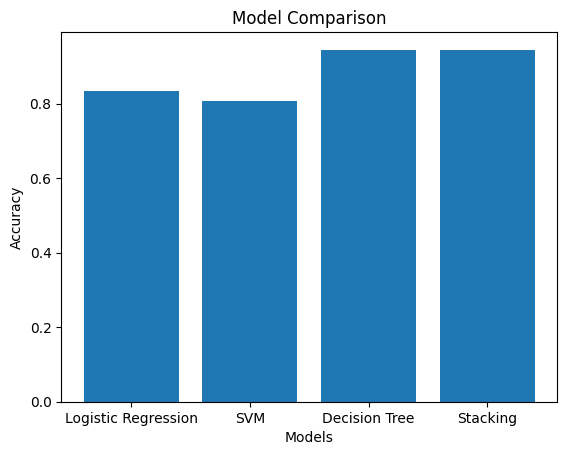

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score

print("Name: Lathika M")
print("Roll No: 24BAD062")
print("Scenario 4 – Stacking")

data = pd.read_csv("/kaggle/input/datasets/lathikamuthuraj/heart-stacking-csv/heart_stacking.csv")

data.columns = data.columns.str.strip()

for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = LabelEncoder().fit_transform(data[col])

X = data.iloc[:,:-1]
y = data.iloc[:,-1]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

lr = LogisticRegression(max_iter=1000)
svm = SVC(probability=True)
dt = DecisionTreeClassifier()

lr.fit(X_train,y_train)
svm.fit(X_train,y_train)
dt.fit(X_train,y_train)

pred_lr = lr.predict(X_test)
pred_svm = svm.predict(X_test)
pred_dt = dt.predict(X_test)

acc_lr = accuracy_score(y_test,pred_lr)
acc_svm = accuracy_score(y_test,pred_svm)
acc_dt = accuracy_score(y_test,pred_dt)

estimators = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('svm', SVC(probability=True)),
    ('dt', DecisionTreeClassifier())
]

stack = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())

stack.fit(X_train,y_train)

pred_stack = stack.predict(X_test)

acc_stack = accuracy_score(y_test,pred_stack)

print("Logistic Regression Accuracy:",acc_lr)
print("SVM Accuracy:",acc_svm)
print("Decision Tree Accuracy:",acc_dt)
print("Stacking Accuracy:",acc_stack)

models = ['Logistic Regression','SVM','Decision Tree','Stacking']
accuracy = [acc_lr,acc_svm,acc_dt,acc_stack]

plt.figure()
plt.bar(models,accuracy)
plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

Name: Lathika M
Roll No: 24BAD062
Scenario 5 – SMOTE
Index(['Amount', 'Time', 'Feature1', 'Feature2', 'Fraud'], dtype='object')
Fraud
0    110
1     10
Name: count, dtype: int64
Before SMOTE
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        34
           1       0.00      0.00      0.00         2

    accuracy                           0.94        36
   macro avg       0.47      0.50      0.49        36
weighted avg       0.89      0.94      0.92        36

Fraud
0    76
1    76
Name: count, dtype: int64
After SMOTE
              precision    recall  f1-score   support

           0       1.00      0.50      0.67        34
           1       0.11      1.00      0.19         2

    accuracy                           0.53        36
   macro avg       0.55      0.75      0.43        36
weighted avg       0.95      0.53      0.64        36



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


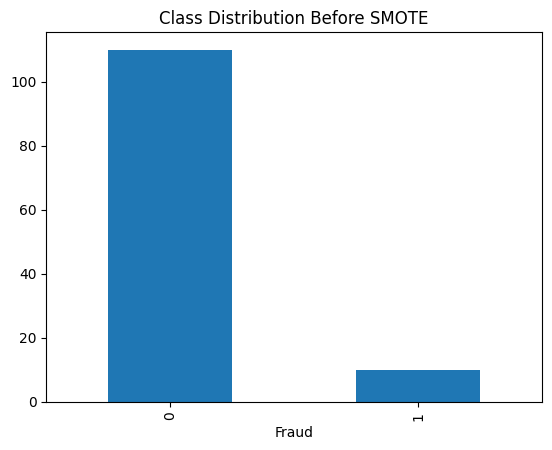

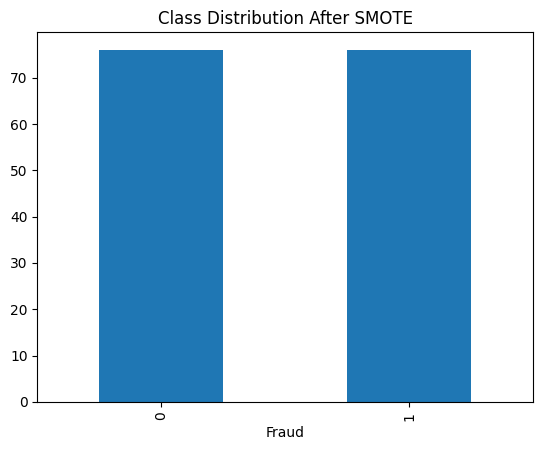

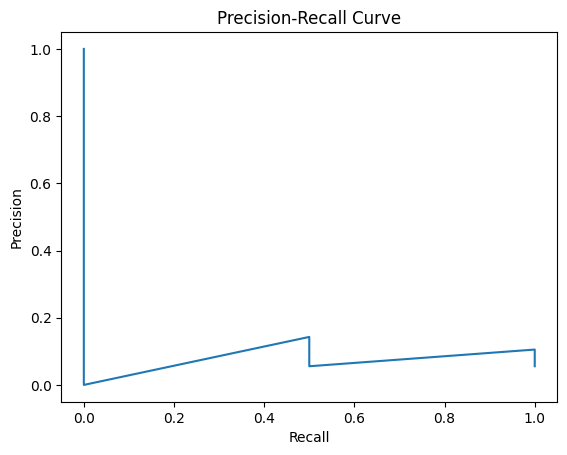

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, precision_recall_curve
from imblearn.over_sampling import SMOTE

print("Name: Lathika M")
print("Roll No: 24BAD062")
print("Scenario 5 – SMOTE")

data = pd.read_csv("/kaggle/input/datasets/lathikamuthuraj/fraud-smote-csv/fraud_smote.csv")

data.columns = data.columns.str.strip()

print(data.columns)

X = data.iloc[:,:-1]
y = data.iloc[:,-1]

print(y.value_counts())

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

model = LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

pred_before = model.predict(X_test)

print("Before SMOTE")
print(classification_report(y_test,pred_before))

smote = SMOTE(random_state=42)

X_train_sm,y_train_sm = smote.fit_resample(X_train,y_train)

print(pd.Series(y_train_sm).value_counts())

model.fit(X_train_sm,y_train_sm)

pred_after = model.predict(X_test)

print("After SMOTE")
print(classification_report(y_test,pred_after))

plt.figure()

y.value_counts().plot(kind='bar')

plt.title("Class Distribution Before SMOTE")

plt.show()

plt.figure()

pd.Series(y_train_sm).value_counts().plot(kind='bar')

plt.title("Class Distribution After SMOTE")

plt.show()

prob = model.predict_proba(X_test)[:,1]

precision,recall,_ = precision_recall_curve(y_test,prob)

plt.plot(recall,precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.show()